Add Project Root to sys.path

In [15]:
import sys, os

# Add project root to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)


Import Libraries    

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.analysis_utils import compute_yearly_averages

Output Table

In [17]:
# Change the path to what suits your machine
df = pd.read_csv('../data/general_merchandise_stores_adjusted.csv', index_col = 0)
print(df)

        JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
YEAR                                                                         
1992  19813  20069  20057  20192  20228  20128  20154  20523  20583  20792   
1993  21233  21327  21225  21677  21923  21822  22217  22219  22415  22570   
1994  22562  23049  23601  23284  23180  23626  23484  23816  23950  24216   
1995  24702  24082  24621  24629  24770  25105  25251  25126  25356  25039   
1996  24914  25570  25489  25938  26232  25985  26059  26414  26585  26869   
1997  27132  27198  27249  27093  27291  27457  27865  27926  27714  28171   
1998  28296  28692  28679  29102  28993  29063  29103  29200  29477  29614   
1999  30555  31024  31289  31015  31183  31632  31511  31723  32260  31979   
2000  32160  32459  33198  32701  33293  33436  33504  33737  33974  34172   
2001  35330  34529  33977  35261  35229  35038  35686  35949  35782  36183   
2002  36718  37008  36939  37355  37127  37333  37028  37022  37

Create Plot

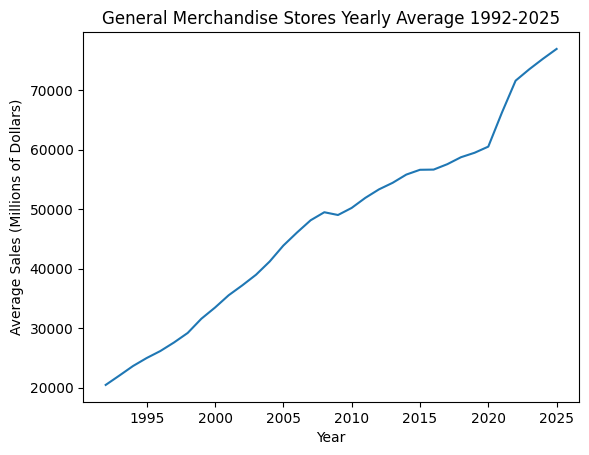

In [18]:
yearly_averages = compute_yearly_averages(df)

plt.plot(df.index, yearly_averages)
plt.title("General Merchandise Stores Yearly Average 1992-2025")
plt.xlabel("Year")
plt.ylabel("Average Sales (Millions of Dollars)")
plt.show()

Unemployment Data

In [19]:
# Unemployment rate only from 2005 - 2025
unemployment_df = pd.read_csv('../data/civilian_unemployment_rate.csv', index_col = 0)

# Cleaning the data
columns_to_drop = ['Men_20plus', 'Women_20plus', 'Age_16_19', 'White', 'Black', 'Asian', 'Hispanic'] # Columns not needed

# Take from November only because that's when the census is taken for general merchandise
unemployment_df = unemployment_df[unemployment_df.index.str.startswith('Nov')]
unemployment_df = unemployment_df.drop(columns=columns_to_drop)
 
# Remove the month name from the column
unemployment_df.index = unemployment_df.index.str[4:]
unemployment_df.index = unemployment_df.index.astype(int) # Convert back to integer

print("Civilian Unemployment Data")
print(unemployment_df)

# Update Average Sales CSV to 2005-2025 only
df = df[df.index >= 2005]

yearly_averages = []

for year in df.index:
    average = df.loc[year].mean()
    yearly_averages.append(average)


# Checking if the data is clean
print("General Merchandise Data")
print(df)


Civilian Unemployment Data
       Total
Month       
2005     5.0
2006     4.5
2007     4.7
2008     6.8
2009     9.9
2010     9.8
2011     8.6
2012     7.7
2013     6.9
2014     5.8
2015     5.1
2016     4.7
2017     4.2
2018     3.8
2019     3.6
2020     6.7
2021     4.2
2022     3.6
2023     3.7
2024     4.2
2025     4.6
General Merchandise Data
        JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
YEAR                                                                         
2005  42404  43026  42732  43495  43317  44356  43910  44102  44282  45165   
2006  45505  45678  45515  45970  45664  45857  45750  46003  46465  46539   
2007  47824  47248  48024  47540  47821  47777  48260  48589  48260  48312   
2008  48796  48795  48786  49393  50181  50745  50491  49862  49349  49140   
2009  49136  49132  48722  48733  48916  48691  48734  48976  48959  49546   
2010  49771  50355  50094  50264  49799  49902  49824  50085  50146  50163   
2011  50726  51301  51474

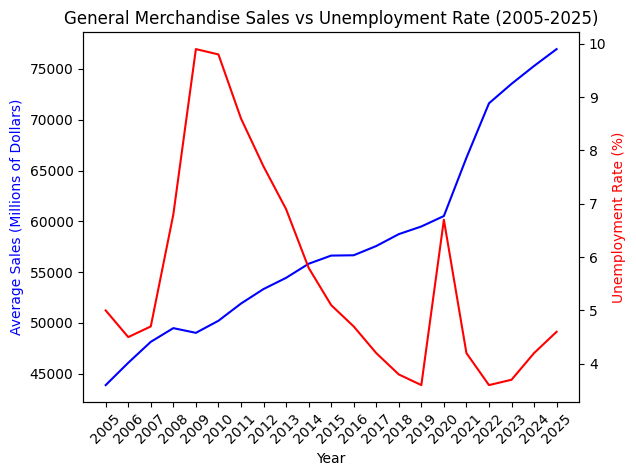

In [20]:
fig, ax1 = plt.subplots()

# Sales (left axis)
ax1.plot(df.index, yearly_averages, label="Average Sales", color="blue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Sales (Millions of Dollars)", color="blue")
ax1.set_xticks(np.arange(2005, 2026, step=1))
plt.xticks(rotation=45)

# Unemployment (right axis)
ax2 = ax1.twinx()
ax2.plot(unemployment_df.index, unemployment_df['Total'], label="Unemployment Rate", color="red")
ax2.set_ylabel("Unemployment Rate (%)", color="red")

# Title
plt.title("General Merchandise Sales vs Unemployment Rate (2005-2025)")

plt.show()

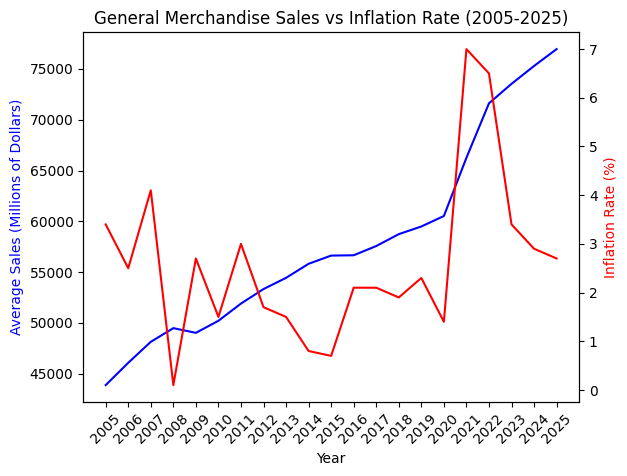

In [21]:
# Inflation rate data from 2005=2025
inflation_df = pd.read_csv('../data/inflation_rate.csv', index_col = 0)

fig, ax1 = plt.subplots()

# Sales (left axis)
ax1.plot(df.index, yearly_averages, label="Average Sales", color="blue")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Sales (Millions of Dollars)", color="blue")
ax1.set_xticks(np.arange(2005, 2026, step=1))
plt.xticks(rotation=45)

# Unemployment (right axis)
ax2 = ax1.twinx()
ax2.plot(inflation_df.index, inflation_df['Inflation Rate'], label="Inflation Rate", color="red")
ax2.set_ylabel("Inflation Rate (%)", color="red")

# Title
plt.title("General Merchandise Sales vs Inflation Rate (2005-2025)")

plt.show()